# Project Foundations for Data Science: FoodHub Data Analysis



### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [166]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [167]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [168]:
# read the data
df = pd.read_csv('/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### Information for dataset

### **Question 1:** How many rows and columns are present in the data?

In [169]:
# Write your code here
rows, columns = df.shape
print(f"Number of rows in dataset: {rows}")
print(f"Number of columns in dataset: {columns}")

Number of rows in dataset: 1898
Number of columns in dataset: 9


#### Observations:
According to '.shape' attribute of pd from panda library, there are 1898 rows and 9 columns in the dataset.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [170]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
According to '.info()' attribute of pd, there are 3 different datatypes in columns.

Datatype-int64:
1. order_id
2. customer_id
3. food_preparation_time
4. delivery_time

Datatype-object:
1. restaurant_name
2. cuisine_type
3. day_of_the_week
4. rating

Datatype-float64:
1. cost_of_the_order

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [171]:
# Check if there is any missing values for any columns in dataset
# Sum null values for each columns
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [172]:
# Sum null values in all columns
df.isnull().sum().sum()

0

#### Observations:
According to code, there is no missing data in dataset, since the sum of null values for all columns is equal to 0.

Also, by contrasting the information of 'info()' and the total rows of each columns, we would be able to know that all 1898 rows is 'Non-Null', which also support there is no missing value in data.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [173]:
# Check statistical summary by '.describe()' attribute of df
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [174]:
# Convert datatype from float(.describe()) to int (data dictionary)
min = df['food_preparation_time'].min().astype(int)
average = df['food_preparation_time'].mean().astype(int)
max = df['food_preparation_time'].max().astype(int)
min,average,max

(20, 27, 35)

#### Observations:
According to the statistical summary above, for column 'food_preparation_time'(in miuntes/Datatype: int64), tranfer value datatype to int type:


minimum time - min:

20min

average time - mean:

27min

maximun time - max:

35min





### **Question 5:** How many orders are not rated?

In [175]:
# Count number of column 'rating' row that value equal to 'Not given'

df['rating'].value_counts(dropna=False)['Not given']

736

#### Observations:
According to code, there are 736 orders is not rated with the value 'Not given'.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration)

#### Before start the univariate, we need to distinguish different type of variables: 1. **categorical** , 2. **continuous** .




##### Determine type of 'rating'
'rating' is special, the values of it are tends to be numbers to better categorize to numeric type, but it can also treated as cateogorical type, when value of rating have very limited unique values, for example: 1,2,3,4,5. In this case, analysis for example '.unique()'is essential:

In [176]:
# Check the unique values in the 'rating' column
unique_ratings = df['rating'].unique()

# Print the unique values
print("Unique ratings in the 'rating' column:", unique_ratings)

Unique ratings in the 'rating' column: ['Not given' '5' '3' '4']


Clean 'rating' column

In [177]:
# Convert the 'rating' column to numeric, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Print the unique values
print("Unique ratings in the 'rating' column:", unique_ratings)

Unique ratings in the 'rating' column: ['Not given' '5' '3' '4']


According to outcome of unique value of 'rating' column, there is only 4 unique value of rating, so we can treat it as categorical variable.

#####In summary, with demonstration for dataset in **Dataset Dictionary** :


**Categorical**- DataType:

1. order_id -
Reason: since serves as unique identifier for each record, values are discrete with no continuous numerical relationship.
2. customer_id -
Reason: since serves as unique identifier for each record, values are discrete with no continuous numerical relationship.
3. restaurant_name -
Reason: restaurant name values are discrete with no continuous numerical relationship.
4. cuisine_type -
Reason: cusine values are discrete with no continuous numerical relationship.
5. day_of_the_week -
Reason: name of day values are discrete with no continuous numerical relationship.
6. rating -
Reason: according to .unique() analysis above, rating values are discrete with no continuous numerical relationship.

**Continuous** - DataType:
1. cost_of_the_order -
Reason: values of cost are continous  with potential continuous numerical relationship.
2. food_preparation_time:
Reason: values of time are continous  with potential continuous numerical relationship.
3. delivery_time:
Reason: values of time are continous  with potential continuous numerical relationship.


In [178]:
continuous_vars = [ 'cost_of_the_order', 'food_preparation_time', 'delivery_time']
categorical_vars = ['order_id', 'customer_id', 'restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating']

#### 1. Countplots - For categorical variables

##### order_id
While **order_id** does not require the same type of univariate analysis as continuous or other types of categorical data, verifying the uniqueness and integrity of these IDs is crucial. This ensures that the dataset is correctly structured for further analysis

In [179]:
# Check for unique values in 'order_id'
unique_ids = df['order_id'].nunique()
total_rows = len(df)

print(f"Total number of orders: {total_rows}")
print(f"Unique order IDs: {unique_ids}")

# Check if the number of unique IDs matches the number of rows
if unique_ids == total_rows:
    print("All order IDs are unique.")
else:
    print("There are duplicate order IDs in the dataset.")

Total number of orders: 1898
Unique order IDs: 1898
All order IDs are unique.


Since all order IDs are unique, and each only occurs once, we do not need plots to visualize it for us.Therefore, exclude 'order_id' from to be plotted categorical variables.

#####  customer_id

In [180]:
# Check for unique values in 'order_id'
unique_ids = df['customer_id'].nunique()
total_rows = len(df)

print(f"Total number of orders: {total_rows}")
print(f"Unique customer IDs: {unique_ids}")

# Check if the number of unique IDs matches the number of rows
if unique_ids == total_rows:
    print("All customer IDs are unique.")
else:
    print("There are duplicate customer IDs in the dataset.")

Total number of orders: 1898
Unique customer IDs: 1200
There are duplicate customer IDs in the dataset.


According to outcome, there are 1200 unique values, so further plot visualization for value frequency can be too crowdy, therefore we exclude the 'customer_id'

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


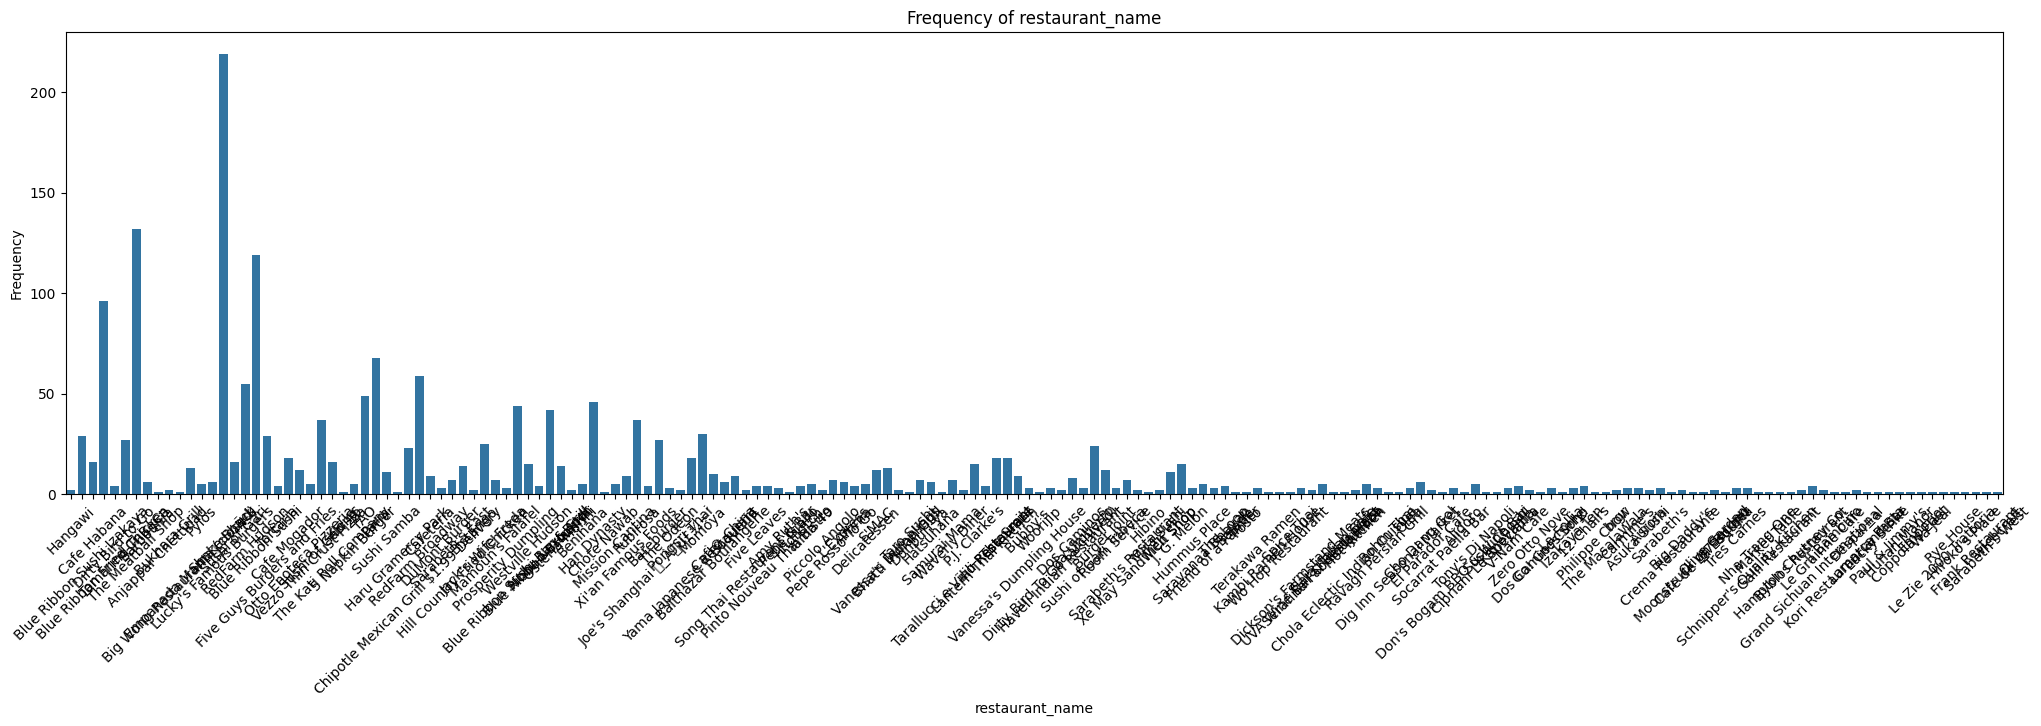

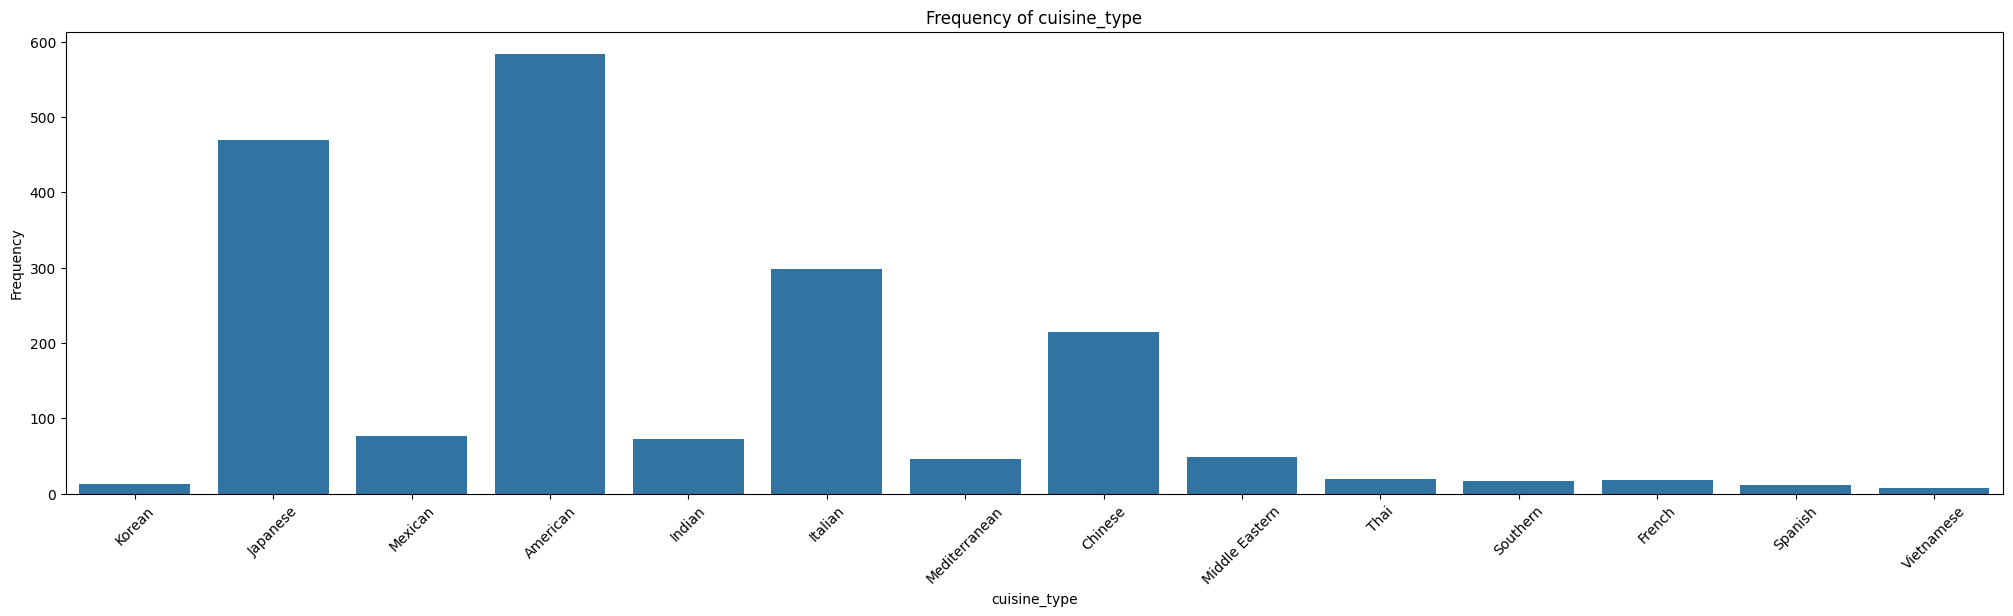

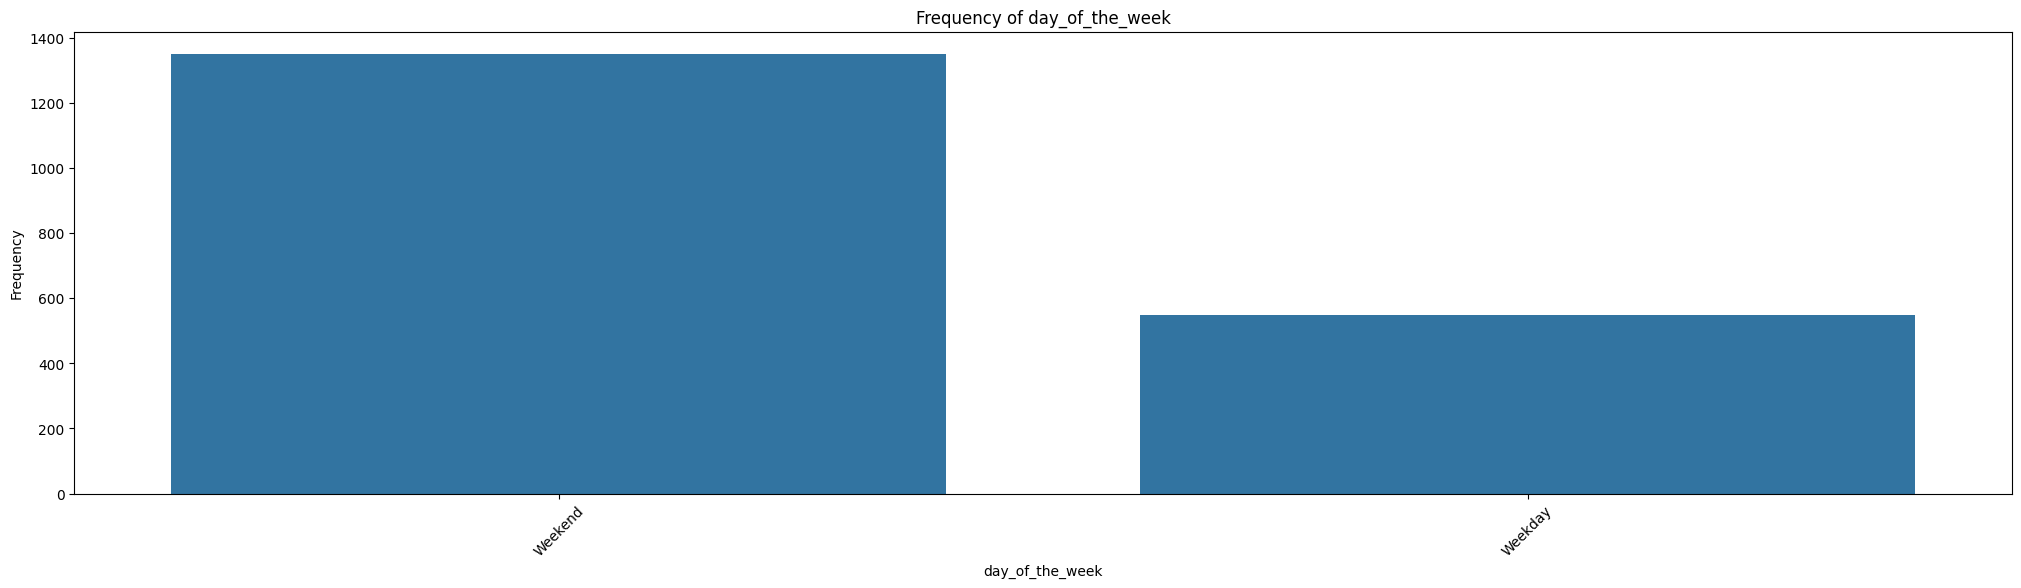

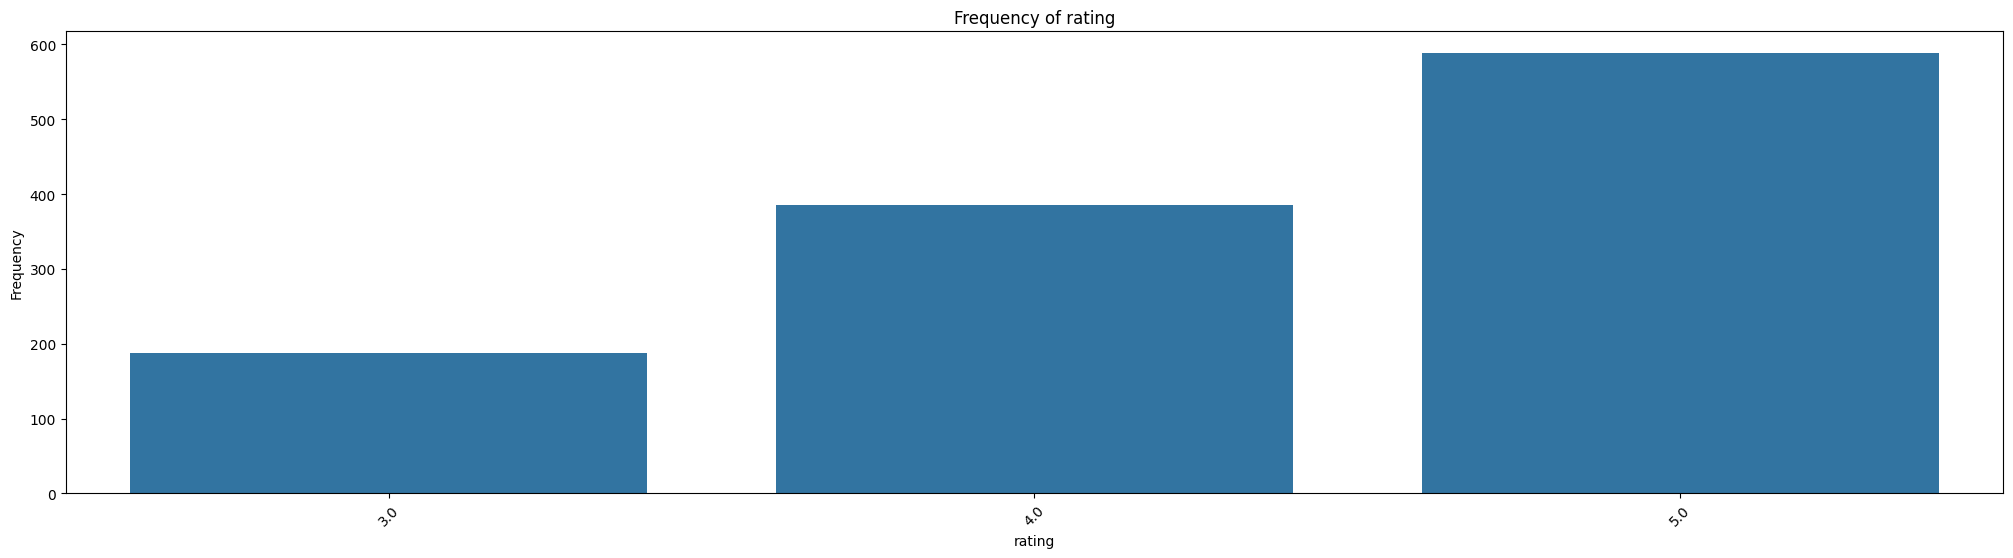

In [181]:
#remove 'order_id','customer_id' from categorical variables list
categorical_vars.remove('order_id')
categorical_vars.remove('customer_id')

# Plot countplots for categorical variables
for var in categorical_vars:
    plt.figure(figsize=(25,6))
    sns.countplot(x=df[var])
    plt.title(f'Frequency of {var}')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

#### 2. Histograms & Boxplots - For continuous variables

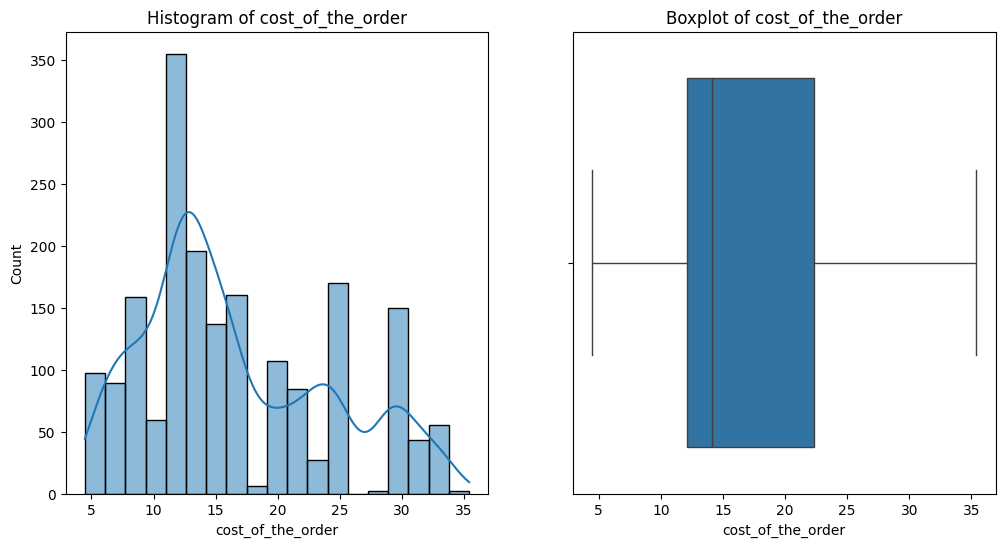

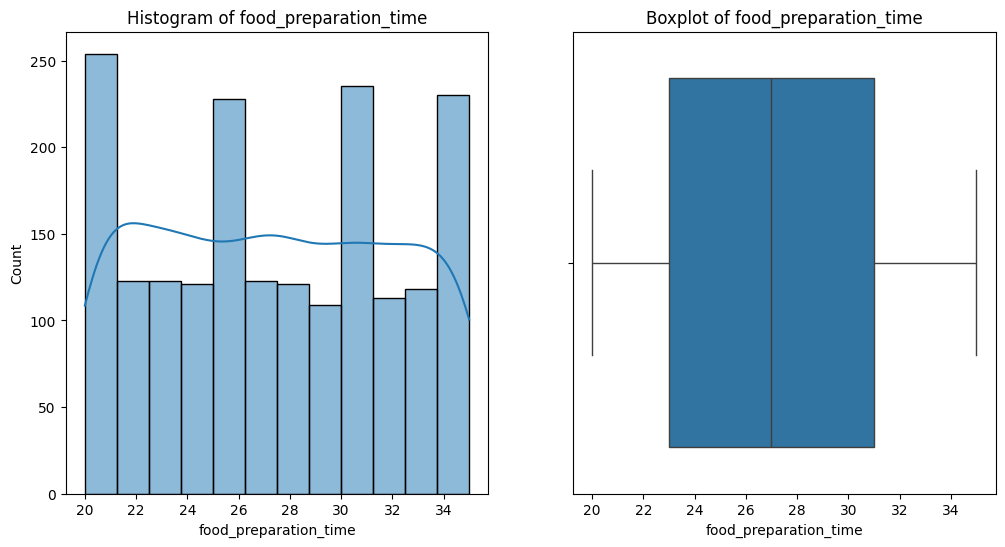

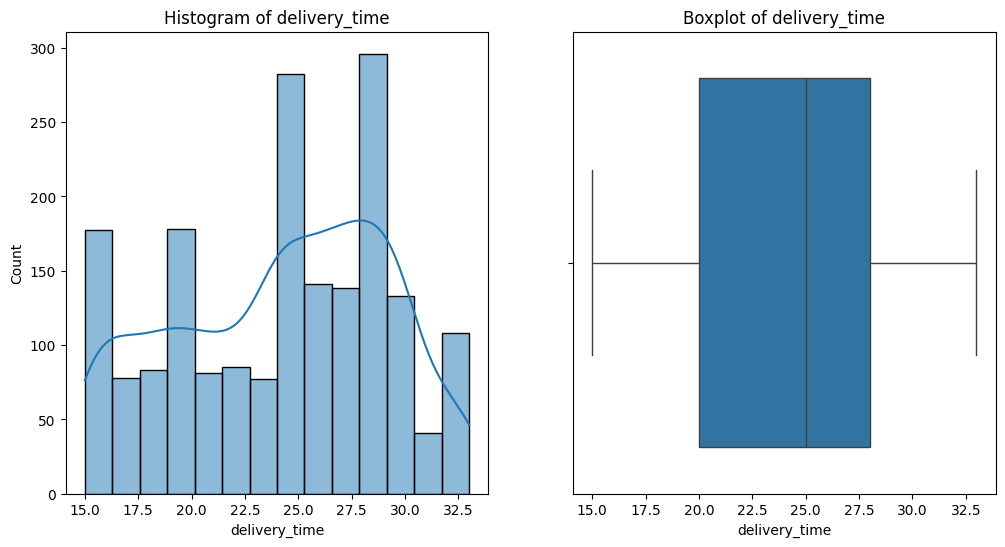

In [182]:
# Plotting for continuous variables
for var in continuous_vars:
    plt.figure(figsize=(12, 6))

    # Histogram
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
    sns.histplot(df[var], kde=True)
    plt.title(f'Histogram of {var}')

    # Boxplot
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot of {var}')

    plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [183]:
# Calculate the frequency of each unique value in the 'restaurant' column
restaurant_counts = df['restaurant_name'].value_counts()

# Get the top 5 most frequent restaurants
top_5_restaurants = restaurant_counts.head(5)

print("Top 5 Frequencies of Restaurants:")
print(top_5_restaurants)

Top 5 Frequencies of Restaurants:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:
The number of orders received of each restaurant is represented in the frequency of each restaurant. According to above code, top 5 restaurant that received order are:

Shake Shack                  219

The Meatball Shop            132

Blue Ribbon Sushi            119

Blue Ribbon Fried Chicken     96

Parm                          68

### **Question 8**: Which is the most popular cuisine on weekends?

In [184]:
# Calculate the frequency of each unique value in the 'cuisine_type' column
weekend = df[df['day_of_the_week'] == 'Weekend']
cuisine_frequency_counts = weekend['cuisine_type'].value_counts()

# Get the most popular
top_cuisine = cuisine_frequency_counts.idxmax()

print("most popular cuisine on weekends:")
print(top_cuisine)

most popular cuisine on weekends:
American


#### Observations:
According to data, take both 'day_of_the_week' and 'cuisine_type' into consider, and most popular cuisine on weekends is 'American'.

### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [185]:
# Rows where orders cost is greater than 20 dollars
orders_above_20 = df[df['cost_of_the_order'] > 20]

# Calculate the percentage of these rows
percentage_above_20 = (len(orders_above_20) / len(df)) * 100

print(f"Percentage of orders costing more than 20 dollars: {percentage_above_20:.2f}%")


Percentage of orders costing more than 20 dollars: 29.24%


#### Observations:
According to above code, Percentage of orders costing more than 20 dollars: 29.24%.

### **Question 10**: What is the mean order delivery time?

In [186]:
# Calculate the mean of the order delivery times in column 'delivery_time'
mean_delivery_time = df['delivery_time'].mean()

print(f"The mean order delivery time is: {mean_delivery_time:.1f} minutes")

The mean order delivery time is: 24.2 minutes


#### Observations:
According to code, The mean order delivery time is: 24.2 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed

In [187]:
# Count the occurrences of each customer_id and get the top 3 most frequent
top_3_customers = df['customer_id'].value_counts().head(3)

print("Top 3 most frequent customers and their number of orders:")
print(top_3_customers)

Top 3 most frequent customers and their number of orders:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:
According to above data, Top 3 most frequent customers_id and their number of orders:

customers_ID :

52832 (13 orders)

47440 (10 orders)

83287 (9 orders)

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)

#### Continuous & Continuous Variables:
Correlation Analysis: Assess the strength and direction of relationships between continuous variables such as 'cost_of_the_order', 'food_preparation_time', and 'delivery_time'.

1. **Correlation Analysis**
2. **Pair Plot/Scatter Plot Matrix**


##### Correlation Analysis
Correlation analysis the relationship between multiple continuous variables. The Pearson correlation coefficient is a commonly used measure that quantifies the degree of linear relationship between two continuous variables. It ranges from -1 to 1, where:

1 indicates a perfect positive linear relationship,

-1 indicates a perfect negative linear relationship,

0 suggests no linear correlation.


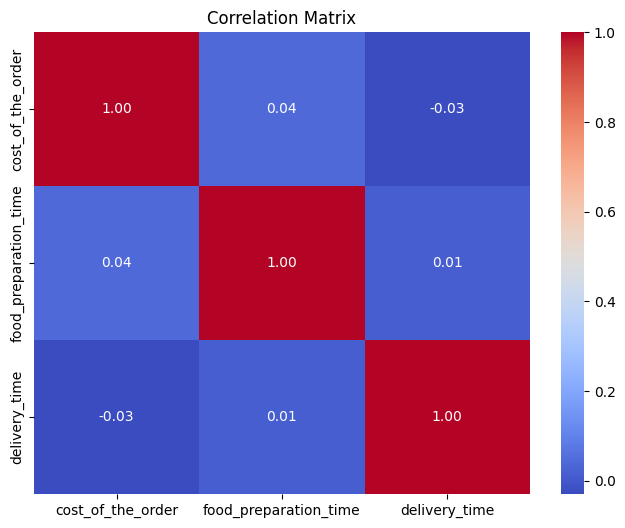

In [188]:
continuous_vars = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

# Calculate the correlation matrix
corr_matrix = df[continuous_vars].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

Oberservation:

'cost_of_the_order' have positive relationship with 'food_preparation_time' and negative relationship with 'delivery_time'.

'delivery_time' have positive relationship with 'food_preparation_time'.

Their all have very little correlation linear relationship since their values are all within range of [−0.1, +0.1].

##### Pair Plot/Scatter Plot Matrix
A pair plot (or scatter plot matrix) is a grid of plots of variables against each other. It includes plots of each variable against itself (histograms or density plots) and plots of variables against each other (scatter plots). This visualization helps to see the distribution of single variables and the relationships between two variables.

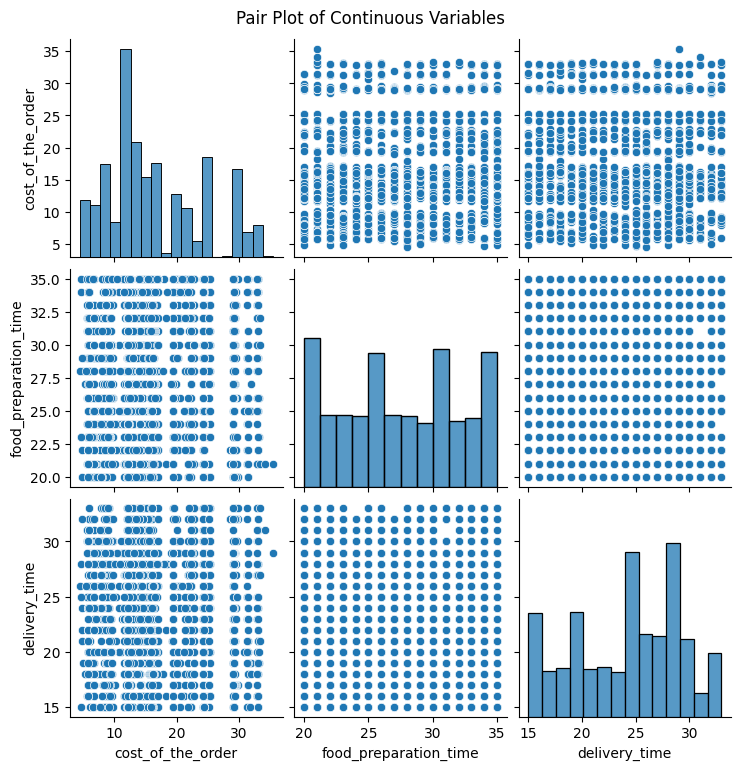

In [189]:
sns.pairplot(df[continuous_vars])
plt.suptitle('Pair Plot of Continuous Variables', y=1.02)
plt.show()

Observation:

From the scatter plots it show fairly dispersed points **without clear linear relationships or trends**, suggesting **low correlation** between pairs, which aligns with the of **correlation values** close to zero from correlation analysis.

For example:

**1. 'delivery_time' vs 'cost_of_the_order'**:
it appears that the points are widely dispersed without a clear directional trend. The scatter points do not cluster around any line nor form any distinct pattern, suggesting that there is likely very little to no linear correlation between these two variables. This could imply:

**Independence:** The time it takes to deliver an order does not seem to be significantly affected by the cost of the order. Higher costs do not necessarily correspond to longer or shorter delivery times.

**Operational Insight:** This might indicate that delivery operations are standardized across different order values, or that other factors (not the cost of the order) play a more critical role in determining delivery times.

**2. 'delivery_time' vs 'food_preparation_time':**
points are dispersed across the plot without any obvious trend or correlation pattern. This indicates:

**Lack of Direct Correlation:** There isn’t a clear indication that longer food preparation times lead to longer or shorter delivery times. This suggests that the delivery process may be somewhat isolated from the preparation process in terms of time management.

**Process Efficiency:** The lack of correlation might suggest that the delivery system operates **independently** of how long the food takes to prepare. This could be a sign of efficient logistics where delivery resources are managed to ensure timely delivery regardless of preparation time.

#### Continuous & Categorical Variables:
1. **Boxplots:** Explore how the continuous variables vary with different categories.
2. **ANOVA or T-tests:** If aiming to see if the means of a continuous variable are different across different groups defined by a categorical variable (like cuisine_type and cost_of_the_order).

##### Boxplots
provide a visual summary of the distribution of a continuous variable across different levels of a categorical variable. They can highlight differences in medians, the spread of data, and potential outliers.

###### cost_of_the_order VS day_of_the_week
create a boxplot to see if orders are typically more expensive on certain days compared to others.

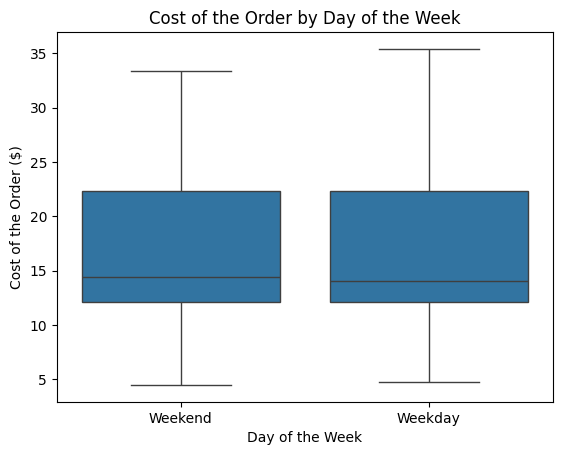

In [190]:
sns.boxplot(x='day_of_the_week', y='cost_of_the_order', data=df)
plt.title('Cost of the Order by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Cost of the Order ($)')
plt.show()

Observation:

There is no obvious difference for cost of order between weekday and weekend.

###### cost_of_the_order VS cuisine_type
Create a boxplot to see if orders are typically more expensive on certain cuisine_type compared to others.

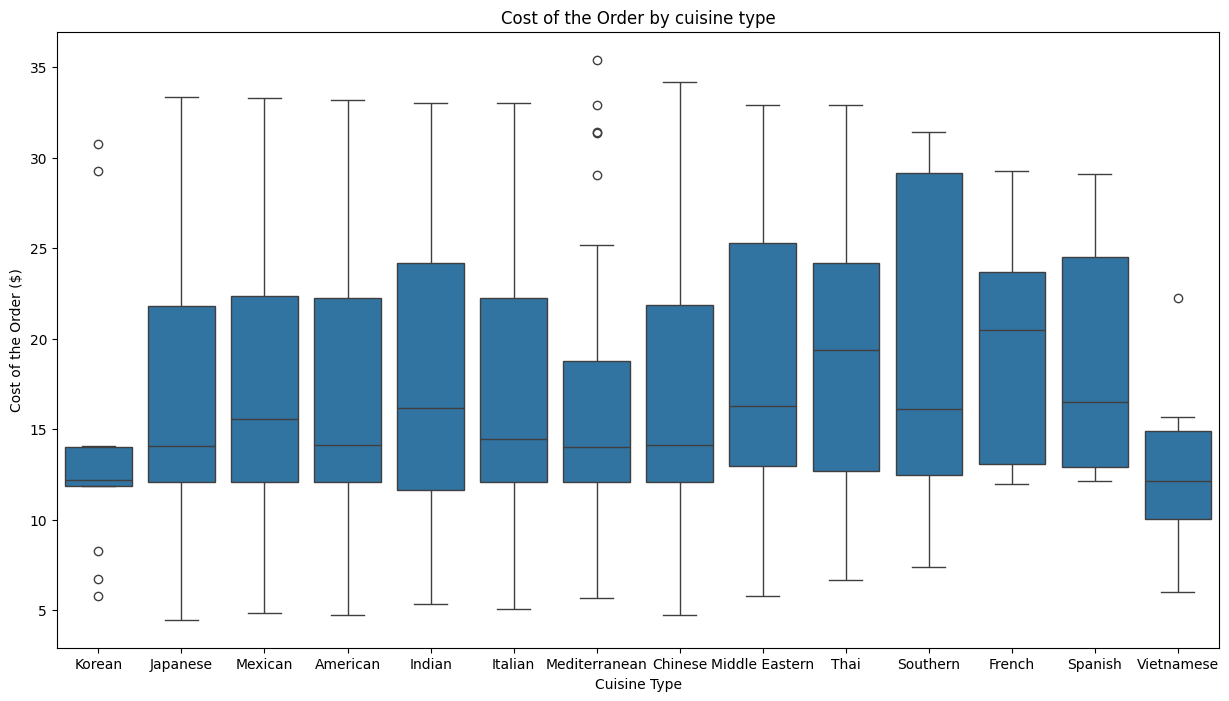

In [191]:
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.title('Cost of the Order by cuisine type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order ($)')
plt.gcf().set_size_inches(15,8)
plt.show()

Oberservation:

**Cuisine Price Variability:** The plot shows a wide variation in the cost of orders among different cuisines. For example, French and Southern cuisines tend to have a higher median cost compared to Korean and Vietnamese cuisines.

**Outliers Analysis:**
Korean Cuisine: The presence of several low outliers suggests that while most Korean orders fall within a higher price range, there are a few orders significantly cheaper than most.
Vietnamese Cuisine: The presence of outliers on the high side indicates that there are a few orders significantly more expensive than the typical range.


**IQR and Spread:**
Mediterranean and Chinese Cuisines: These cuisines show a relatively larger IQR, indicating a higher variability in order prices within these cuisines.
Vietnamese Cuisine: Shows a narrow box but has outliers, suggesting that most orders are concentrated around a lower median cost, but there are exceptions.

**Business Implications:**
Understanding which cuisines tend to have higher variability in order costs can help in pricing strategy adjustments or in managing customer expectations.


**Quality and Service Analysis:** Outliers, especially in cost data, can suggest special cases like orders that included premium items or perhaps errors in data entry. They could also reflect special promotions or discounts that significantly altered the typical order cost.

##### ANOVA/ T-tests
Purpose:

**T-tests:** Compare the means of a continuous variable between two groups within a categorical variable.

**ANOVA (Analysis of Variance)**: Extend this comparison to more than two groups.


Benefits:

Hypothesis Testing:
Statistically test if there are significant differences in the means across groups.

Multiple Groups Analysis: ANOVA can handle comparisons across more than two groups, unlike T-tests which are limited to two.

######food_preparation_time VS cuisine_type

In [192]:
from scipy import stats
grouped_data = [group['food_preparation_time'].values for name, group in df.groupby('cuisine_type')]

# Performing ANOVA
f_val, p_val = stats.f_oneway(*grouped_data)
print('ANOVA results: F-Value=', f_val, ' P-Value=', p_val)

ANOVA results: F-Value= 0.5759803592089382  P-Value= 0.8748929883169041


Obersevation:

**F-Value:** This is the test statistic for ANOVA, which compares the variance between the groups to the variance within the groups. A higher F-value typically indicates a greater likelihood that there are significant differences between the means of the groups being compared.

F-Value = 0.576: This relatively low F-value suggests that the variance explained by the group mean (between-group variance) is not much larger than the variance within each group (within-group variance). This indicates that the group means are relatively similar.


**P-Value:** This value tells us the probability of obtaining an effect at least as extreme as the one in your sample data, assuming the null hypothesis is true. The null hypothesis for an ANOVA test is that there are no differences among group means.

P-Value = 0.875: A p-value greater than 0.05 (common threshold for statistical significance) strongly suggests that you **fail to reject the null hypothesis**. In plain terms, there is not sufficient evidence to conclude that there are significant differences in the food_preparation_time across different cuisine_type.

Implications of the ANOVA Results


**No Significant Differences:** Since the p-value is much higher than 0.05, it implies that the differences in food_preparation_time among the different cuisine_type groups are statistically insignificant. This suggests that the type of cuisine does not significantly influence the preparation time in the context of your dataset.


**Uniformity in Operations:** The results may indicate that food preparation processes are standardized across different cuisines to a certain degree, leading to similar preparation times despite the diversity in cuisine types.
Future Analysis: If you were expecting differences or if operational experience suggests differences should exist, it might be worth examining other factors or potential issues with the data. Considerations might include sample size, variability within groups, or other operational variables not included in this analysis.


#### Categorical & Categorical
1. **Cross Tabulation and Chi-Square Tests:** Evaluate the independence between categorical variables, like cuisine_type and day_of_the_week.

  

*   **Cross Tabulation:** This method helps in summarizing the relationship
    between two categorical variables in the form of a table. It shows the frequency (or count) of each combination of categories from the two variables.

*  **Chi-Square Test for Independence:** This statistical test is used to determine whether there is a significant relationship between two categorical variables. The test is applied to the table generated by cross tabulation.


2. **Stacked Bar Charts:** Visualize the distribution of one categorical variable within another, such as the proportion of each cuisine_type within each day_of_the_week.

###### Cross Tabulation and Chi-Square Tests - Cuisine type VS Day of the *week*

In [193]:
from scipy.stats import chi2_contingency
# Creating a cross-tabulation
ct = pd.crosstab(df['cuisine_type'], df['day_of_the_week'])

# Conducting the Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(ct)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", pd.DataFrame(expected, index=ct.index, columns=ct.columns))

# Decision based on the p-value
if p_value < 0.05:
    print("Reject the null hypothesis - There is a significant relationship between the two categorical variables.")
else:
    print("Fail to reject the null hypothesis - There is no significant relationship between the two categorical variables.")

Chi-Square Statistic: 9.547288225517978
P-value: 0.7304685567606379
Degrees of Freedom: 13
Expected Frequencies:
 day_of_the_week     Weekday     Weekend
cuisine_type                           
American         168.307692  415.692308
Chinese           61.962592  153.037408
French             5.187566   12.812434
Indian            21.038462   51.961538
Italian           85.883035  212.116965
Japanese         135.453109  334.546891
Korean             3.746575    9.253425
Mediterranean     13.257113   32.742887
Mexican           22.191254   54.808746
Middle Eastern    14.121707   34.878293
Southern           4.899368   12.100632
Spanish            3.458377    8.541623
Thai               5.475764   13.524236
Vietnamese         2.017387    4.982613
Fail to reject the null hypothesis - There is no significant relationship between the two categorical variables.


Oberservation:

Fail to reject the null hypothesis - There is no significant relationship between the two categorical variables.



###### Stacked Bar Charts - Cuisine type VS Day of the week
Purpose: Stacked bar charts are excellent for visualizing the distribution of categories of one variable within the categories of another variable. It allows us to see proportions as well as absolute comparisons.

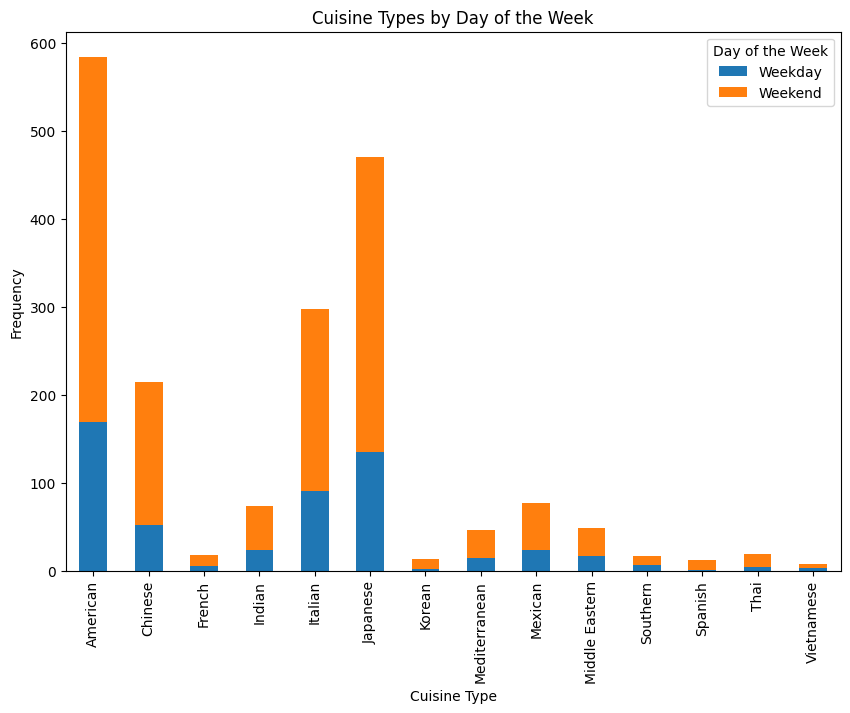

In [194]:
ct.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title("Cuisine Types by Day of the Week")
plt.xlabel("Cuisine Type")
plt.ylabel("Frequency")
plt.legend(title="Day of the Week")
plt.show()

**Obeservation:**

1. General Trends:
*   The chart displays a significant variation in the popularity of different cuisines on weekdays versus weekends.
*   Some cuisines, like American, Chinese, and Italian, show a high total frequency of orders, indicating general popularity.



2. Weekday vs. Weekend Analysis:

*   American Cuisine: Dominates in frequency on both weekdays and weekends, but particularly high on weekdays. This suggests a steady demand throughout the week with a potential peak during weekdays.
*   Chinese Cuisine: Similar to American cuisine, it shows higher orders on weekdays, suggesting it is a popular choice for weekday dining.
Italian Cuisine: Shows a notable balance between weekday and weekend orders, indicating consistent popularity across the week.


3. Lower Frequency Cuisines:

*   Cuisines like Thai and Vietnamese show very low frequencies overall, with minimal distinction between weekday and weekend. This could imply either a niche market or limited availability.
*   Korean Cuisine: Notably higher on weekends, which might suggest it is preferred as a weekend treat or outing cuisine.


4. Middle Eastern and Southern Cuisines:


*   These cuisines show an interesting pattern with a slightly higher or exclusive preference during the weekend. This could be due to cultural dining habits or special weekend menus.

**Implication:**


1.   Marketing and Promotion: The data can guide targeted marketing strategies. For instance, promoting American and Chinese cuisines as ideal choices for quick weekday meals could capitalize on their popularity. Conversely, weekend promotions might focus on Korean and Middle Eastern cuisines to draw in crowds looking for special weekend meals.
2.   Menu Planning: Understanding which cuisines are popular on which days can help restaurants plan their menu offerings and staffing requirements more effectively. For example, ensuring adequate supplies and staff for American and Chinese cuisine during the weekdays and for Korean and Middle Eastern during the weekends.
3. Strategic Expansion: For restaurants looking to expand their offerings, understanding popular cuisines and their daily distribution can inform decisions on what cuisines might be promising to introduce or expand upon.













### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer

In [195]:
# Group by restaurant name to calculate count of ratings and average rating
grouped = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filter the restaurants based on the given criteria
promotional_restaurants = grouped[(grouped['count'] > 50) & (grouped['mean'] > 4)]

print(promotional_restaurants)

                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905


#### Observations:
The fullfiled restaurant are:
1. Blue Ribbon Fried Chicken 2. Blue Ribbon Sushi 3. Shake Shack 4. The Meatball Shop    

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders

In [196]:
#Define method for commission computation
def calculate_commission(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Apply the commission calculation to each row
df['commission'] = df['cost_of_the_order'].apply(calculate_commission)

# Sum up the total commission to get the net revenue
total_revenue = df['commission'].sum()

print(f"Net revenue generated by the company: ${total_revenue:.2f}")

Net revenue generated by the company: $6166.30


#### Observations:
According to data, Net revenue generated by the company is $6166.30.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered)

In [197]:
# Calculate the total time for each order/row
df['total_time'] = df['delivery_time'] + df['food_preparation_time']

# Determine the number of orders that take more than 60 minutes
orders_over_60 = df[df['total_time'] > 60].shape[0]

# Calculate the total number of orders
total_orders = df.shape[0]

# Calculate the percentage of orders taking more than 60 minutes
percentage_over_60 = (orders_over_60 / total_orders) * 100

print(f"Percentage of orders taking more than 60 minutes: {percentage_over_60:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:
Accordind to calculation, Percentage of orders taking more than 60 minutes is 10.54%

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [198]:
# Group by 'day_of_week' and calculate the mean delivery time
mean_delivery_time = df.groupby('day_of_the_week')['delivery_time'].mean()

formatted_delivery_time = mean_delivery_time.apply(lambda x: f"{x:.2f}")

print(formatted_delivery_time)

day_of_the_week
Weekday    28.34
Weekend    22.47
Name: delivery_time, dtype: object


#### Observations:
Mean delivery time for weekday and weekend respectively are: 28.34 minutes and 22.47 minutes respectively.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations)

### Conclusions:
1. Customer Preferences by Day of the Week:

    American, Chinese, and Italian Cuisines: These cuisines are highly popular, with American cuisine showing a particularly strong preference during weekdays. This indicates a consistent demand for these cuisines throughout the week.
    
    Korean and Middle Eastern Cuisines: These show a higher preference during weekends, suggesting they might be seen as more of a weekend treat or special occasion food.

2. Delivery Time Analysis:

    Mean Delivery Times: The mean delivery times do not show a significant difference between weekdays and weekends based on the given data. This suggests that the delivery system is fairly consistent across different days of the week.

3. Order Preparation and Delivery Times:

    Total Time Calculation: A significant percentage of orders take more than 60 minutes from preparation to delivery, which could indicate a bottleneck in either the preparation or delivery process, or both.

4. Revenue from Orders:

    Commission Structure: The company generates substantial revenue from orders, especially those over $20, where a 25% commission is applied.

5. Restaurant Ratings:

    Promotional Criteria: Only a subset of restaurants meet the criteria for promotions (more than 50 ratings and an average rating above 4), indicating that there is room for improvement in customer satisfaction across the board.



### Recommendations:

1. Targeted Marketing Campaigns:

  Weekday Promotions: Focus on promoting American, Chinese, and Italian cuisines during weekdays. Consider offering special lunch deals or discounts to attract office workers and regular weekday customers.

  Weekend Specials: Promote Korean and Middle Eastern cuisines during weekends. Special weekend menus, discounts, or events could drive higher sales and cater to the preference for these cuisines as weekend treats.

2. Improving Delivery Efficiency:

  Analyze Bottlenecks: Investigate the reasons behind orders taking more than 60 minutes. This could involve looking into the preparation process for certain cuisines or improving the logistics of the delivery system.

  Streamline Processes: Implement process improvements in the kitchen to reduce preparation times and use data-driven approaches to optimize delivery routes.


3. Enhancing Customer Satisfaction:

  Feedback Utilization: Actively use customer feedback and ratings to identify areas for improvement. Restaurants with lower ratings should be given specific feedback and support to improve their service quality.

  Incentivize Feedback: Encourage customers to leave ratings and reviews by offering small incentives. More feedback will provide better insights and more data to drive improvements.


4. Revenue Optimization:

  Dynamic Pricing: Consider dynamic pricing strategies for peak hours to maximize revenue. This can involve higher prices during rush hours with the justification of ensuring quicker delivery times.

  Commission Structure Review: Regularly review the commission structure to ensure it is competitive and fair, encouraging restaurants to partner with the platform while also maximizing revenue.


5. Expanding Popular Offerings:

  Menu Expansion: Based on popular cuisines, encourage restaurants to expand their menu offerings to include popular dishes. This can be particularly effective for restaurants that may not currently serve American, Chinese, or Italian cuisines.

  Promotions for High-Rating Restaurants: Highlight and promote restaurants that meet the high-rating criteria in advertising campaigns. This not only rewards these restaurants but also sets a standard for others to strive for.


6. Customer Engagement and Loyalty Programs:

  Loyalty Programs: Implement loyalty programs that reward frequent customers, especially those who consistently, frequently order on weekdays or weekends. This can help increase customer retention and repeat business.

  Personalized Recommendations: Use data analytics to provide personalized recommendations to customers based on their order history and preferences. This can enhance the customer experience and increase order frequency.


---